In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [149]:
df = pd.read_csv("Position_Salaries.csv")

In [150]:
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [151]:
# dimension of df
print(df.shape)

(10, 3)


In [152]:
print(df.head())

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


In [153]:
#view dataframe summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [154]:
#view descriptive analysis

df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [155]:
# Declare feature variable and target variable
X = df['Level'].values # Sales and Advertising data values are given by X
y = df['Salary'].values # Sales and Advertising data values are given by Y


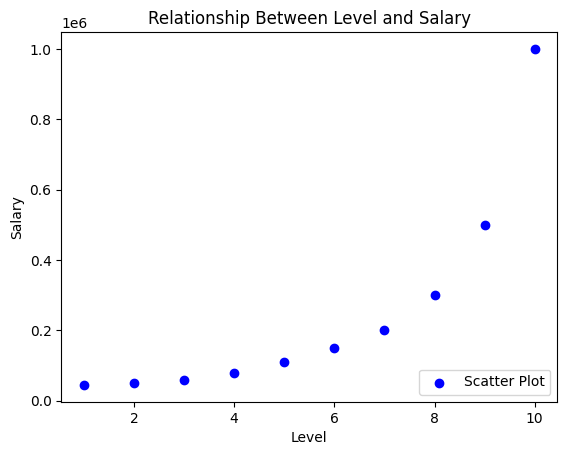

In [156]:
#plot the scatter between x and y
plt.scatter(X,y,color="blue",label="Scatter Plot")
plt.title("Relationship Between Level and Salary")
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend(loc=4)
plt.show()

In [157]:
#print the dimensions of x and y

X.shape

(10,)

In [158]:
y.shape

(10,)

In [159]:
#reshaping x and y
X=X.reshape(-1,1)

y=y.reshape(-1,1)

In [160]:
#print the dimensions of x and y after reshaping
X.shape

(10, 1)

In [161]:
y.shape

(10, 1)

In [162]:
#Split X and y into training and test data sets
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [163]:
# print the dimensions of X_train, X_test, y_train, y_test
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)

print(y_test.shape)

(8, 1)
(2, 1)
(8, 1)
(2, 1)


In [164]:
#fit the linear model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [165]:
#compute model slope and intercept
a=model.coef_
b=model.intercept_
print("Estimated Model Coefficient:",a)



print("Estimated intercept of Model:",b)

Estimated Model Coefficient: [[87887.93103448]]
Estimated intercept of Model: [-240258.62068966]


In [166]:

model.predict(X)[0:5]#predicting the value for the first 5 advertising value

array([[-152370.68965517],
       [ -64482.75862069],
       [  23405.17241379],
       [ 111293.10344828],
       [ 199181.03448276]])

In [167]:
# to make an individual prediction using the linear regression model
print(str(model.predict(X)[[6
                            ]]))

[[374956.89655172]]


In [168]:
#calculate the root mean squared error
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 88544.09867029045


In [169]:
#caluclating the r2 score
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.8451346684575974


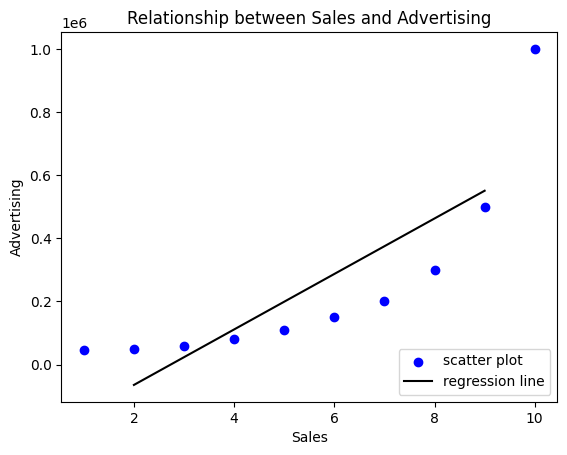

In [170]:
#plot the regression line
plt.scatter(X,y,color="blue",label="scatter plot")
plt.plot(X_test,y_pred,color="black",label="regression line")
plt.title('Relationship between Sales and Advertising')
plt.xlabel('Sales')
plt.ylabel('Advertising')
plt.legend(loc=4)
plt.show()


In [171]:
#checking for overfitting or underfitting of the model
print("Training Set score:",model.score(X_train,y_train))
print("Testing Set score:",model.score(X_test,y_test))

Training Set score: 0.6366049276570868
Testing Set score: 0.8451346684575974
